# 0. Dual Access Control — notebook principal de presentación y defensa

**Problema:** una credencial RFID identifica un UID, pero no prueba que quien la porta sea su titular.  
**Solución:** segundo factor facial basado en verificación de pares con una CNN siamesa.  
**Tecnologías:** Python, TensorFlow/Keras, OpenCV, pandas, Matplotlib, FastAPI y SQLite local.  
**Modelo final:** `baseline_formal/baseline_con_aumento`.  
**Threshold operativo:** `0.3128704727` (`score >= threshold => MATCH`).  
**Objetivo de la demo:** demostrar la regla `RFID conocido + usuario activo + rostro verificado => GRANTED`.

> **Qué demuestra este notebook.** Metodología, EDA agregado, control experimental, resultados, calibración, análisis de errores, integración funcional, reproducibilidad, limitaciones y ética, sin exponer rostros ni datos personales y sin ejecutar entrenamiento.


In [1]:
from pathlib import Path
import json
import warnings

import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display

pd.set_option('display.max_colwidth', 100)
pd.set_option('display.float_format', lambda value: f'{value:.4f}' if isinstance(value, float) else str(value))
plt.rcParams.update({'figure.dpi': 95, 'axes.grid': True, 'grid.alpha': 0.25})

def find_project_root():
    candidates = [Path.cwd(), *Path.cwd().parents]
    for candidate in candidates:
        if (candidate / 'config' / 'model_config.json').is_file():
            return candidate
    raise FileNotFoundError('No se encontró la raíz del proyecto desde el directorio actual.')

ROOT = find_project_root()
SUMMARY = ROOT / 'outputs' / 'summary'
FINAL_DIR = ROOT / 'outputs' / 'experiments' / 'baseline_formal' / 'baseline_con_aumento'
MODEL_COMPARISON = ROOT / 'outputs' / 'experiments' / 'model_comparison'
BASELINE_COMPARISON = ROOT / 'outputs' / 'experiments' / 'baseline_formal' / 'comparison'

def rel(path):
    return Path(path).relative_to(ROOT).as_posix()

def read_json(path):
    path = Path(path)
    if not path.is_file():
        raise FileNotFoundError(f'Falta evidencia requerida: {rel(path)}')
    return json.loads(path.read_text(encoding='utf-8'))

dataset = read_json(SUMMARY / 'dataset_aggregate_summary.json')
users = pd.read_csv(SUMMARY / 'images_per_user.csv')
views = pd.read_csv(SUMMARY / 'images_per_view.csv')
model_config = read_json(ROOT / 'config' / 'model_config.json')
training_config = read_json(FINAL_DIR / 'training_config.json')
calibration = read_json(FINAL_DIR / 'security_threshold_calibration' / 'security_threshold_calibration.json')
augmentation_clean = pd.read_csv(BASELINE_COMPARISON / 'clean_test_comparison.csv')
baseline_comparison_json = read_json(BASELINE_COMPARISON / 'comparison_summary.json')
threshold_metrics = pd.read_csv(MODEL_COMPARISON / 'threshold_metrics.csv')
photometric = pd.read_csv(MODEL_COMPARISON / 'photometric_metrics.csv')
stress_all = pd.read_csv(MODEL_COMPARISON / 'stress_metrics_security_first.csv')

assert model_config['model_name'] == 'baseline_formal/baseline_con_aumento'
assert abs(model_config['threshold'] - 0.3128704727) < 1e-10
print('Evidencia agregada y artefactos versionados cargados correctamente. No se cargó el modelo ni el dataset privado.')


Evidencia agregada y artefactos versionados cargados correctamente. No se cargó el modelo ni el dataset privado.


In [2]:
agenda = pd.DataFrame([
    ('Contexto', 'Problema, objetivo e indicadores'),
    ('Datos', 'EDA agregado, limpieza, pares y split sin fuga'),
    ('Modelo', 'Baseline, entrenamiento y técnicas aplicadas'),
    ('Experimentos', 'Aumento, operating points y variante GAP'),
    ('Resultados', 'Métricas, threshold, matriz y stress tests'),
    ('Producto', 'Inferencia modular, demo web y pruebas'),
    ('Crítica', 'Limitaciones, futuro, reproducibilidad y ética'),
    ('Defensa', 'Matriz de rúbrica y preguntas clave'),
], columns=['Bloque', 'Contenido'])
display(agenda.style.hide(axis='index'))


Bloque,Contenido
Contexto,"Problema, objetivo e indicadores"
Datos,"EDA agregado, limpieza, pares y split sin fuga"
Modelo,"Baseline, entrenamiento y técnicas aplicadas"
Experimentos,"Aumento, operating points y variante GAP"
Resultados,"Métricas, threshold, matriz y stress tests"
Producto,"Inferencia modular, demo web y pruebas"
Crítica,"Limitaciones, futuro, reproducibilidad y ética"
Defensa,Matriz de rúbrica y preguntas clave


## 1. Problema y justificación de Deep Learning

Una tarjeta RFID puede prestarse, perderse, copiarse o ser robada. El UID identifica una credencial registrada; **no garantiza identidad humana**. El segundo factor compara la captura facial con las referencias asociadas al UID.

Este proyecto no formula una clasificación cerrada de 11 clases. Formula **verificación de pares**: estima si dos imágenes corresponden o no a la misma persona. Luz, pose, cámara, escala, encuadre y oclusión producen variaciones no lineales que no se cubren de manera robusta con reglas manuales. La red siamesa aprende una representación compartida y una función de similitud; por ello pueden enrolarse nuevas referencias sin reentrenar un clasificador por identidad.

> **Formulación del problema:** verificar que la persona que presenta un UID conocido y activo coincide con sus referencias faciales, y denegar de forma segura cualquier caso que no satisfaga ambos factores.

**Fuentes:** `docs/final_methodology.md` §1; `src/inference/decision.py`; `src/web/services.py`.


## 2. Objetivo general e indicadores de éxito

**Objetivo medible:** construir un prototipo reproducible que asocie un UID con un usuario, verifique su rostro mediante una red siamesa y registre la decisión, usando un operating point seleccionado en validation con el criterio operativo `FAR <= 2%` y `FRR <= 5%`.

Las metas son operativas y documentales; no se inventa una meta retrospectiva para accuracy o AUC. Test se consultó después de fijar el threshold.


In [3]:
final_row = threshold_metrics[
    threshold_metrics['model'].eq('baseline_con_aumento') &
    threshold_metrics['criterion'].eq('security_first')
].iloc[0]
indicators = pd.DataFrame([
    ('Accuracy', 'Reportar junto con FAR/FRR', final_row.test_accuracy, 'Reportado'),
    ('Precision', 'Confiabilidad de MATCH', final_row.test_precision, 'Reportado'),
    ('Recall', 'Aceptación de genuinos', final_row.test_recall, 'Reportado'),
    ('F1', 'Equilibrio precision/recall', final_row.test_f1, 'Reportado'),
    ('FAR', 'Selección en validation: <= 0.02', final_row.test_far, 'Cumple en test limpio'),
    ('FRR', 'Selección en validation: <= 0.05', final_row.test_frr, 'Cumple en test limpio'),
    ('ROC AUC', 'Separación independiente del threshold', final_row.test_roc_auc, 'Reportado'),
    ('Matriz de confusión', 'Mostrar TN/FP/FN/TP', '245 / 5 / 12 / 238', 'Reportado'),
    ('Registro e historial', 'Flujo funcional disponible', 'OK', 'Evidenciado por pruebas'),
    ('GRANTED y rechazos', 'UID correcto, desconocido, inactivo y no-match', 'OK', 'Evidenciado por pruebas'),
], columns=['Indicador', 'Meta o criterio', 'Resultado', 'Estado'])
display(indicators.style.hide(axis='index'))
print('Fuente cuantitativa:', rel(MODEL_COMPARISON / 'threshold_metrics.csv'))


Indicador,Meta o criterio,Resultado,Estado
Accuracy,Reportar junto con FAR/FRR,0.966000,Reportado
Precision,Confiabilidad de MATCH,0.979424,Reportado
Recall,Aceptación de genuinos,0.952000,Reportado
F1,Equilibrio precision/recall,0.965517,Reportado
FAR,Selección en validation: <= 0.02,0.020000,Cumple en test limpio
FRR,Selección en validation: <= 0.05,0.048000,Cumple en test limpio
ROC AUC,Separación independiente del threshold,0.983776,Reportado
Matriz de confusión,Mostrar TN/FP/FN/TP,245 / 5 / 12 / 238,Reportado
Registro e historial,Flujo funcional disponible,OK,Evidenciado por pruebas
GRANTED y rechazos,"UID correcto, desconocido, inactivo y no-match",OK,Evidenciado por pruebas


Fuente cuantitativa: outputs/experiments/model_comparison/threshold_metrics.csv


## 3. Dataset y análisis exploratorio autosuficiente

El notebook usa archivos agregados anónimos y versionados. Puede presentarse sin el dataset privado. Las identidades se sustituyeron por `user_001`–`user_011`; no se guardan nombres, imágenes, videos ni rutas de origen.

**Alcance del EDA:** volumen, aceptación/rechazo, distribución por usuario y vista, splits, videos, pares y balance binario.


In [4]:
d = dataset['dataset']
dataset_table = pd.DataFrame([
    ('Personas', d['people']), ('Videos', d['videos']),
    ('Imágenes detectadas', d['images_detected']),
    ('Imágenes utilizables', d['images_usable']),
    ('Imágenes rechazadas', d['images_rejected']),
    ('Porcentaje rechazado', f"{100*d['rejection_rate']:.2f}%"),
], columns=['Indicador', 'Valor'])
split_table = pd.DataFrame(dataset['splits']).rename(columns={
    'split':'Split', 'images':'Imágenes', 'videos':'Videos', 'pairs':'Pares',
    'positive_pairs':'Pares positivos', 'negative_pairs':'Pares negativos'
})
display(dataset_table.style.hide(axis='index'))
display(split_table.style.hide(axis='index'))
display(views.rename(columns={'view':'Vista','images_detected':'Detectadas','images_usable':'Utilizables','images_rejected':'Rechazadas'}).style.hide(axis='index'))
print('Fuentes:', rel(SUMMARY / 'dataset_aggregate_summary.json'), ',', rel(SUMMARY / 'images_per_view.csv'))


Indicador,Valor
Personas,11
Videos,44
Imágenes detectadas,1702
Imágenes utilizables,1544
Imágenes rechazadas,158
Porcentaje rechazado,9.28%


Split,Imágenes,Videos,Pares,Pares positivos,Pares negativos
train,739,22,4000,2000,2000
validation,400,11,500,250,250
test,405,11,500,250,250


Vista,Detectadas,Utilizables,Rechazadas
frontal,453,453,0
left,420,371,49
mixed,438,398,40
right,391,322,69


Fuentes: outputs/summary/dataset_aggregate_summary.json , outputs/summary/images_per_view.csv


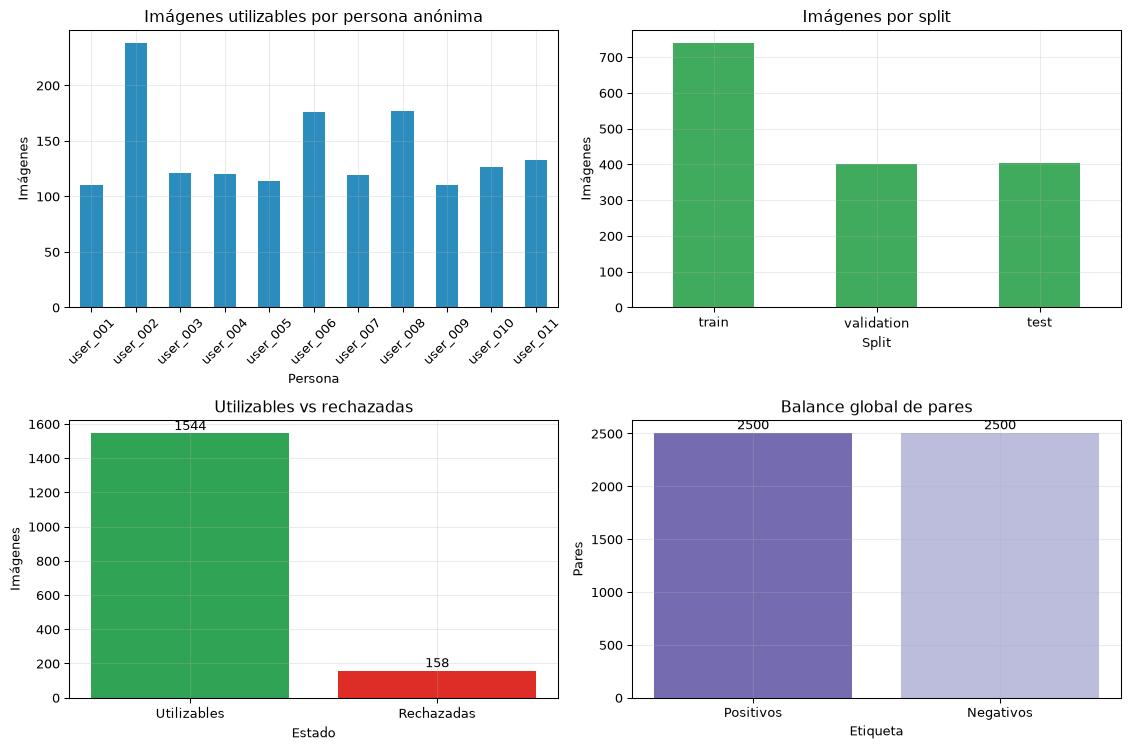

Fuente por persona: outputs/summary/images_per_user.csv


In [5]:
fig, axes = plt.subplots(2, 2, figsize=(12, 8))
users.plot.bar(x='user_id', y='images_usable', ax=axes[0,0], legend=False, color='#2b8cbe')
axes[0,0].set(title='Imágenes utilizables por persona anónima', xlabel='Persona', ylabel='Imágenes')
axes[0,0].tick_params(axis='x', rotation=45)

split_table.plot.bar(x='Split', y='Imágenes', ax=axes[0,1], legend=False, color='#41ab5d')
axes[0,1].set(title='Imágenes por split', xlabel='Split', ylabel='Imágenes')
axes[0,1].tick_params(axis='x', rotation=0)

axes[1,0].bar(['Utilizables', 'Rechazadas'], [d['images_usable'], d['images_rejected']], color=['#31a354','#de2d26'])
axes[1,0].set(title='Utilizables vs rechazadas', xlabel='Estado', ylabel='Imágenes')
for i, value in enumerate([d['images_usable'], d['images_rejected']]): axes[1,0].text(i, value+20, str(value), ha='center')

positive = split_table['Pares positivos'].sum(); negative = split_table['Pares negativos'].sum()
axes[1,1].bar(['Positivos', 'Negativos'], [positive, negative], color=['#756bb1','#bcbddc'])
axes[1,1].set(title='Balance global de pares', xlabel='Etiqueta', ylabel='Pares')
for i, value in enumerate([positive, negative]): axes[1,1].text(i, value+40, str(value), ha='center')

fig.tight_layout(); plt.show()
print('Fuente por persona:', rel(SUMMARY / 'images_per_user.csv'))


**Lectura crítica del EDA.** Hay solo 11 identidades y una distribución desigual: entre 110 y 238 imágenes utilizables por persona. Las vistas laterales concentran rechazos. Las mismas identidades aparecen en los tres splits, aunque los videos no se cruzan. Las condiciones de captura son limitadas; por ello los resultados no demuestran generalización demográfica ni hacia identidades completamente nuevas.


## 4. Limpieza, transformación y generación de pares

`video → fotogramas → detección facial → recorte con margen → control de calidad → 112×112 → RGB → float32/[0,1] → pares positivos/negativos`

Los pares positivos usan la misma identidad y los negativos identidades distintas. La normalización ocurre en el dataloader para mantener un contrato único de entrada.


In [6]:
quality = pd.DataFrame([
    ('Detección', 'Cara válida; mínimo 60×60 y área >= 1% del frame', 'src/preprocessing/face_crop.py'),
    ('Recorte', 'Margen 20% alrededor del bounding box', 'src/preprocessing/face_crop.py'),
    ('Nitidez', 'Varianza Laplaciana >= 30', 'src/preprocessing/clean_faces.py'),
    ('Brillo', 'Media en gris entre 35 y 220', 'src/preprocessing/clean_faces.py'),
    ('Contraste', 'Desviación estándar en gris >= 15', 'src/preprocessing/clean_faces.py'),
    ('Re-detección', 'Al menos una detección dentro del recorte', 'src/preprocessing/clean_faces.py'),
    ('Entrada', 'RGB 112×112×3, float32, rango [0,1]', 'src/dataset/dataloader.py'),
], columns=['Etapa/criterio', 'Implementación verificada', 'Fuente'])
display(quality.style.hide(axis='index'))
reasons = pd.DataFrame(dataset['documented_rejection_reasons']).rename(columns={'reason':'Razón documentada','count':'Imágenes'})
display(reasons.style.hide(axis='index'))
print('Nota: el manifiesto documenta 79 rechazos por no detectar rostro en el recorte y 79 sin detalle histórico; no se atribuyen causas no registradas.')


Etapa/criterio,Implementación verificada,Fuente
Detección,Cara válida; mínimo 60×60 y área >= 1% del frame,src/preprocessing/face_crop.py
Recorte,Margen 20% alrededor del bounding box,src/preprocessing/face_crop.py
Nitidez,Varianza Laplaciana >= 30,src/preprocessing/clean_faces.py
Brillo,Media en gris entre 35 y 220,src/preprocessing/clean_faces.py
Contraste,Desviación estándar en gris >= 15,src/preprocessing/clean_faces.py
Re-detección,Al menos una detección dentro del recorte,src/preprocessing/clean_faces.py
Entrada,"RGB 112×112×3, float32, rango [0,1]",src/dataset/dataloader.py


Razón documentada,Imágenes
no_face_detected_in_crop,79
sin_detalle_en_manifest_historico,79


Nota: el manifiesto documenta 79 rechazos por no detectar rostro en el recorte y 79 sin detalle histórico; no se atribuyen causas no registradas.


## 5. División sin fuga y auditoría

El error metodológico inicial consistía en formar todos los pares y dividir después: frames iguales o altamente correlacionados podían cruzar splits. La corrección convierte el video en unidad indivisible.

`manifest → split por video → pares dentro de cada split → auditoría`

Las identidades aparecen en train, validation y test, pero no se cruzan videos ni imágenes. Este protocolo evalúa **nuevas capturas de identidades conocidas**; no equivale a generalizar sobre identidades no vistas.


In [7]:
protocol = pd.DataFrame([
    ('Pares primero y split después', 'Imágenes o frames relacionados podían cruzarse', 'Split de videos antes de generar pares'),
], columns=['Protocolo inicial', 'Problema', 'Protocolo corregido'])
audit_map = {
    'Imágenes compartidas': dataset['leakage_audit']['shared_images'],
    'Videos compartidos': dataset['leakage_audit']['shared_videos'],
    'Pares repetidos': dataset['leakage_audit']['duplicate_pairs'],
    'Hashes cruzados': dataset['leakage_audit']['cross_split_hashes'],
}
audit = pd.DataFrame([(k,v,'OK' if v == 0 else 'REVISAR') for k,v in audit_map.items()], columns=['Control', 'Hallazgos', 'Estado'])
display(protocol.style.hide(axis='index'))
display(audit.style.hide(axis='index'))
print('Fuentes:', rel(SUMMARY / 'dataset_aggregate_summary.json'), '; src/dataset/audit_splits.py; docs/dataset_protocol.md')


Protocolo inicial,Problema,Protocolo corregido
Pares primero y split después,Imágenes o frames relacionados podían cruzarse,Split de videos antes de generar pares


Control,Hallazgos,Estado
Imágenes compartidas,0,OK
Videos compartidos,0,OK
Pares repetidos,0,OK
Hashes cruzados,0,OK


Fuentes: outputs/summary/dataset_aggregate_summary.json ; src/dataset/audit_splits.py; docs/dataset_protocol.md


## 6. Modelo baseline

Dos entradas `112×112×3` pasan por **el mismo encoder**: los pesos se comparten. La distancia absoluta L1 entre embeddings alimenta una salida sigmoide de similitud.

```text
imagen A ─┐                         ┌─ embedding A ─┐
          ├─ encoder compartido ───┤               ├─ |A-B| ─ sigmoid ─ score
imagen B ─┘                         └─ embedding B ─┘
```

**Implementación modular:** `src/models/siamese_network.py` — `build_embedding_network()` y `build_siamese_model()`.


In [8]:
architecture = pd.DataFrame([
    ('Entradas', '2 × 112×112×3', 'Par facial'),
    ('Bloque 1', 'Conv2D 64 + BatchNorm + MaxPool', '112→56'),
    ('Bloque 2', 'Conv2D 128 + BatchNorm + MaxPool', '56→28'),
    ('Bloque 3', 'Conv2D 256 + BatchNorm + MaxPool', '28→14'),
    ('Bloque 4', 'Conv2D 256 + BatchNorm + MaxPool', '14→7'),
    ('Vectorización', 'Flatten', '7×7×256'),
    ('Proyección', 'Dense 256 + Dropout 0.3', 'Regularización'),
    ('Embedding', 'Dense 128', 'Características aprendidas'),
    ('Comparación', 'Distancia L1', '|embedding A - embedding B|'),
    ('Salida', 'Dense 1, sigmoid', 'Score de similitud'),
], columns=['Componente', 'Capa/operación', 'Salida o función'])
display(architecture.style.hide(axis='index'))
print('Parámetros totales del modelo siamés: 4,208,257')
print('Fuente: src/models/siamese_network.py; docs/final_methodology.md §6.1')


Componente,Capa/operación,Salida o función
Entradas,2 × 112×112×3,Par facial
Bloque 1,Conv2D 64 + BatchNorm + MaxPool,112→56
Bloque 2,Conv2D 128 + BatchNorm + MaxPool,56→28
Bloque 3,Conv2D 256 + BatchNorm + MaxPool,28→14
Bloque 4,Conv2D 256 + BatchNorm + MaxPool,14→7
Vectorización,Flatten,7×7×256
Proyección,Dense 256 + Dropout 0.3,Regularización
Embedding,Dense 128,Características aprendidas
Comparación,Distancia L1,|embedding A - embedding B|
Salida,"Dense 1, sigmoid",Score de similitud


Parámetros totales del modelo siamés: 4,208,257
Fuente: src/models/siamese_network.py; docs/final_methodology.md §6.1


## 7. Configuración de entrenamiento

Esta sección **documenta** la ejecución histórica. El notebook no invoca TensorFlow ni ejecuta `fit()`.


In [9]:
training_table = pd.DataFrame([
    ('Loss', 'Binary Crossentropy', 'Problema binario MATCH/NO_MATCH', 'src/models/siamese_network.py'),
    ('Optimizer', 'Adam', 'Optimización estable del baseline', 'src/models/siamese_network.py'),
    ('Learning rate', training_config['learning_rate'], 'Paso bajo para dataset acotado', rel(FINAL_DIR/'training_config.json')),
    ('Batch size', training_config['batch_size'], 'Balance entre memoria y gradiente', rel(FINAL_DIR/'training_config.json')),
    ('Épocas', training_config['epochs_max'], 'Máximo controlado; se completaron 10', rel(FINAL_DIR/'training_config.json')),
    ('Patience', training_config['early_stopping']['patience'], 'Detener si val_loss no mejora', rel(FINAL_DIR/'training_config.json')),
    ('Seed', training_config['seed'], 'Python, NumPy y TensorFlow', 'src/training/train.py'),
    ('Augmentation', 'Solo train', 'Robustez sin alterar validation/test', rel(FINAL_DIR/'training_config.json')),
    ('Callback', 'EarlyStopping + CSVLogger', 'Control y trazabilidad', 'src/training/train.py'),
    ('Checkpoint', 'Mejor val_loss; época 8', 'save_best_only=True', rel(FINAL_DIR/'training_config.json')),
    ('Hardware baseline', 'CPU, Windows nativo', 'Ejecución histórica del baseline', 'docs/baseline_training_results.md'),
], columns=['Elemento', 'Valor', 'Justificación', 'Fuente'])
display(training_table.style.hide(axis='index'))


Elemento,Valor,Justificación,Fuente
Loss,Binary Crossentropy,Problema binario MATCH/NO_MATCH,src/models/siamese_network.py
Optimizer,Adam,Optimización estable del baseline,src/models/siamese_network.py
Learning rate,0.000100,Paso bajo para dataset acotado,outputs/experiments/baseline_formal/baseline_con_aumento/training_config.json
Batch size,64,Balance entre memoria y gradiente,outputs/experiments/baseline_formal/baseline_con_aumento/training_config.json
Épocas,10,Máximo controlado; se completaron 10,outputs/experiments/baseline_formal/baseline_con_aumento/training_config.json
Patience,5,Detener si val_loss no mejora,outputs/experiments/baseline_formal/baseline_con_aumento/training_config.json
Seed,42,"Python, NumPy y TensorFlow",src/training/train.py
Augmentation,Solo train,Robustez sin alterar validation/test,outputs/experiments/baseline_formal/baseline_con_aumento/training_config.json
Callback,EarlyStopping + CSVLogger,Control y trazabilidad,src/training/train.py
Checkpoint,Mejor val_loss; época 8,save_best_only=True,outputs/experiments/baseline_formal/baseline_con_aumento/training_config.json


## 8. Control y registro de experimentos

Cada experimento conserva configuración, historial, predicciones, métricas y gráficos en una carpeta propia. Arquitectura/datos/optimizer/lr/batch/seed/épocas/checkpoint se mantuvieron constantes en la comparación con/sin aumento. Test no participó en entrenamiento ni selección de threshold.


In [10]:
stress_avg = {}
for name, payload in baseline_comparison_json['variants'].items():
    rows = pd.DataFrame(payload['stress'])
    stress_avg[name] = (rows['accuracy'].mean(), rows['frr'].mean())
experiments = pd.DataFrame([
    ('baseline_con_aumento', 'Aumentos mejoran robustez', 'Augmentation de train activado', 'Arquitectura, datos, Adam, lr, batch, seed 42', f"Test F1={augmentation_clean.iloc[0].f1:.4f}; stress acc prom.={stress_avg['con_aumento'][0]:.4f}", 'Seleccionado'),
    ('baseline_sin_aumento', 'Cuantificar aporte del aumento', 'Augmentation de train desactivado', 'Mismas constantes', f"Test F1={augmentation_clean.iloc[1].f1:.4f}; stress acc prom.={stress_avg['sin_aumento'][0]:.4f}", 'No seleccionado'),
    ('siamese_gap_l2_cosine', 'Menos parámetros y mejor robustez', 'GAP, L2 y coseno', 'Datos, augmentation, lr, batch, seed 42', 'Mejor limpio; FRR fotométrico 0.82–1.00', 'Descartado'),
    ('max_f1 vs security_first', 'Reducir FAR sin ocultar FRR', 'Operating point', 'Mismas predicciones; calibración validation', 'FP test 9→5; FN 1→12', 'security_first final'),
], columns=['Experimento', 'Hipótesis', 'Variable modificada', 'Variables constantes', 'Resultado', 'Decisión'])
display(experiments.style.hide(axis='index'))
print('Seeds: 42 (entrenamiento) y 2026 (stress). Fuentes: outputs/experiments/baseline_formal/ y outputs/experiments/model_comparison/.')


Experimento,Hipótesis,Variable modificada,Variables constantes,Resultado,Decisión
baseline_con_aumento,Aumentos mejoran robustez,Augmentation de train activado,"Arquitectura, datos, Adam, lr, batch, seed 42",Test F1=0.9803; stress acc prom.=0.9502,Seleccionado
baseline_sin_aumento,Cuantificar aporte del aumento,Augmentation de train desactivado,Mismas constantes,Test F1=0.9780; stress acc prom.=0.8282,No seleccionado
siamese_gap_l2_cosine,Menos parámetros y mejor robustez,"GAP, L2 y coseno","Datos, augmentation, lr, batch, seed 42",Mejor limpio; FRR fotométrico 0.82–1.00,Descartado
max_f1 vs security_first,Reducir FAR sin ocultar FRR,Operating point,Mismas predicciones; calibración validation,FP test 9→5; FN 1→12,security_first final


Seeds: 42 (entrenamiento) y 2026 (stress). Fuentes: outputs/experiments/baseline_formal/ y outputs/experiments/model_comparison/.


## 9. Técnicas de Deep Learning aplicadas

Las técnicas efectivamente implementadas se separan de propuestas futuras.


In [11]:
applied = pd.DataFrame([
    ('CNN siamesa y pesos compartidos', 'Implementada', 'src/models/siamese_network.py'),
    ('Embeddings aprendidos de 128 componentes', 'Implementada', 'src/models/siamese_network.py'),
    ('BatchNormalization y Dropout 0.3', 'Implementada', 'src/models/siamese_network.py'),
    ('Distancia L1 + sigmoid', 'Implementada', 'src/models/siamese_network.py'),
    ('Augmentation solo train', 'Implementada', 'src/dataset/augmentations.py'),
    ('Early stopping y checkpoint', 'Implementada', 'src/training/train.py'),
    ('Calibración de threshold', 'Implementada', 'src/evaluation/calibrate_security_thresholds.py'),
    ('Stress tests deterministas', 'Implementada; seed 2026', 'src/evaluation/stress_tests.py'),
    ('GAP + L2 + coseno', 'Implementada y entrenada; 1,062,400 parámetros', 'src/models/siamese_variants.py'),
], columns=['Técnica', 'Estado', 'Evidencia'])
display(applied.style.hide(axis='index'))


Técnica,Estado,Evidencia
CNN siamesa y pesos compartidos,Implementada,src/models/siamese_network.py
Embeddings aprendidos de 128 componentes,Implementada,src/models/siamese_network.py
BatchNormalization y Dropout 0.3,Implementada,src/models/siamese_network.py
Distancia L1 + sigmoid,Implementada,src/models/siamese_network.py
Augmentation solo train,Implementada,src/dataset/augmentations.py
Early stopping y checkpoint,Implementada,src/training/train.py
Calibración de threshold,Implementada,src/evaluation/calibrate_security_thresholds.py
Stress tests deterministas,Implementada; seed 2026,src/evaluation/stress_tests.py
GAP + L2 + coseno,"Implementada y entrenada; 1,062,400 parámetros",src/models/siamese_variants.py


## 10. Técnicas evaluadas y no priorizadas

- El encoder CNN propio sí aprende características, pero **no es un extractor preentrenado**.
- MobileNetV2 congelado se analizó como alternativa futura; no se entrenó dentro del protocolo final.
- No hubo fine-tuning porque no se consolidó primero un backbone preentrenado y 11 identidades elevan el riesgo de sobreajuste.
- No hubo knowledge distillation: no existía un teacher validado ni una necesidad crítica de compresión antes de resolver fuga, robustez e integración.


In [12]:
not_implemented = pd.DataFrame([
    ('Extractor preentrenado / MobileNetV2', 'No implementado', 'Evaluado conceptualmente', 'Probar backbone congelado con validation-stress separado'),
    ('Fine-tuning', 'No implementado', 'No aplicable sin backbone consolidado', 'Liberar últimos bloques con lr reducido tras baseline transferido'),
    ('Teacher-student / distillation', 'No implementado', 'Sin teacher superior validado', 'Evaluar solo si existe objetivo real de compresión'),
], columns=['Técnica', 'Estado real', 'Justificación', 'Propuesta futura'])
display(not_implemented.style.hide(axis='index'))
print('Fuente: docs/final_methodology.md §§6.1–6.3; docs/siamese_model_improvement.md §Variante fotométrica y MobileNetV2.')


Técnica,Estado real,Justificación,Propuesta futura
Extractor preentrenado / MobileNetV2,No implementado,Evaluado conceptualmente,Probar backbone congelado con validation-stress separado
Fine-tuning,No implementado,No aplicable sin backbone consolidado,Liberar últimos bloques con lr reducido tras baseline transferido
Teacher-student / distillation,No implementado,Sin teacher superior validado,Evaluar solo si existe objetivo real de compresión


Fuente: docs/final_methodology.md §§6.1–6.3; docs/siamese_model_improvement.md §Variante fotométrica y MobileNetV2.


## 11. Métricas seleccionadas

En control de acceso, **FAR y FRR son más interpretables que accuracy por sí sola**: distinguen intrusiones aceptadas de usuarios legítimos rechazados.


In [13]:
metric_definitions = pd.DataFrame([
    ('Accuracy', 'Proporción total correcta', 'Resumen global; puede ocultar tipos de error'),
    ('Precision', 'MATCH correctos entre MATCH predichos', 'Confiabilidad de una aceptación facial'),
    ('Recall', 'Genuinos aceptados', 'Disponibilidad para usuarios legítimos'),
    ('F1', 'Media armónica precision/recall', 'Equilibra ambos sin sustituir FAR/FRR'),
    ('FAR', 'Impostores aceptados / negativos', 'Riesgo de acceso indebido'),
    ('FRR', 'Genuinos rechazados / positivos', 'Fricción y posible denegación injusta'),
    ('ROC AUC', 'Separación a todos los thresholds', 'Compara ranking sin fijar operating point'),
], columns=['Métrica', 'Qué mide', 'Por qué importa aquí'])
display(metric_definitions.style.hide(axis='index'))


Métrica,Qué mide,Por qué importa aquí
Accuracy,Proporción total correcta,Resumen global; puede ocultar tipos de error
Precision,MATCH correctos entre MATCH predichos,Confiabilidad de una aceptación facial
Recall,Genuinos aceptados,Disponibilidad para usuarios legítimos
F1,Media armónica precision/recall,Equilibra ambos sin sustituir FAR/FRR
FAR,Impostores aceptados / negativos,Riesgo de acceso indebido
FRR,Genuinos rechazados / positivos,Fricción y posible denegación injusta
ROC AUC,Separación a todos los thresholds,Compara ranking sin fijar operating point


## 12. Comparación de experimentos

Cada tabla indica su operating point. La comparación con/sin aumento usa el `max_f1` propio de cada variante; la comparación de modelos y el modelo final usa `security_first`. No se mezclan thresholds sin indicarlo.


In [14]:
aug_view = augmentation_clean[['variant','threshold','accuracy','f1','far','frr','roc_auc']].copy()
aug_view['operating_point'] = 'max_f1 de cada variante'
display(aug_view.style.hide(axis='index'))

threshold_view = threshold_metrics[
    threshold_metrics['model'].eq('baseline_con_aumento') &
    threshold_metrics['criterion'].isin(['max_f1','security_first'])
][['criterion','threshold','validation_far','validation_frr','validation_f1','test_accuracy','test_f1','test_far','test_frr','test_fp','test_fn']]
display(threshold_view.style.hide(axis='index'))

model_view = threshold_metrics[threshold_metrics['criterion'].eq('security_first')][
    ['model','threshold','test_accuracy','test_f1','test_far','test_frr','test_roc_auc']
]
display(model_view.style.hide(axis='index'))
print('Fuentes:', rel(BASELINE_COMPARISON/'clean_test_comparison.csv'), ',', rel(MODEL_COMPARISON/'threshold_metrics.csv'))


variant,threshold,accuracy,f1,far,frr,roc_auc,operating_point
con_aumento,0.018788,0.980000,0.980315,0.036000,0.004000,0.983776,max_f1 de cada variante
sin_aumento,0.045924,0.978000,0.978044,0.024000,0.020000,0.995744,max_f1 de cada variante


criterion,threshold,validation_far,validation_frr,validation_f1,test_accuracy,test_f1,test_far,test_frr,test_fp,test_fn
max_f1,0.018788,0.024000,0.008000,0.984127,0.980000,0.980315,0.036000,0.004000,9,1
security_first,0.312870,0.020000,0.028000,0.975904,0.966000,0.965517,0.020000,0.048000,5,12


model,threshold,test_accuracy,test_f1,test_far,test_frr,test_roc_auc
baseline_con_aumento,0.312870,0.966000,0.965517,0.020000,0.048000,0.983776
siamese_gap_l2_cosine,0.955118,0.974000,0.973523,0.008000,0.044000,0.998096


Fuentes: outputs/experiments/baseline_formal/comparison/clean_test_comparison.csv , outputs/experiments/model_comparison/threshold_metrics.csv


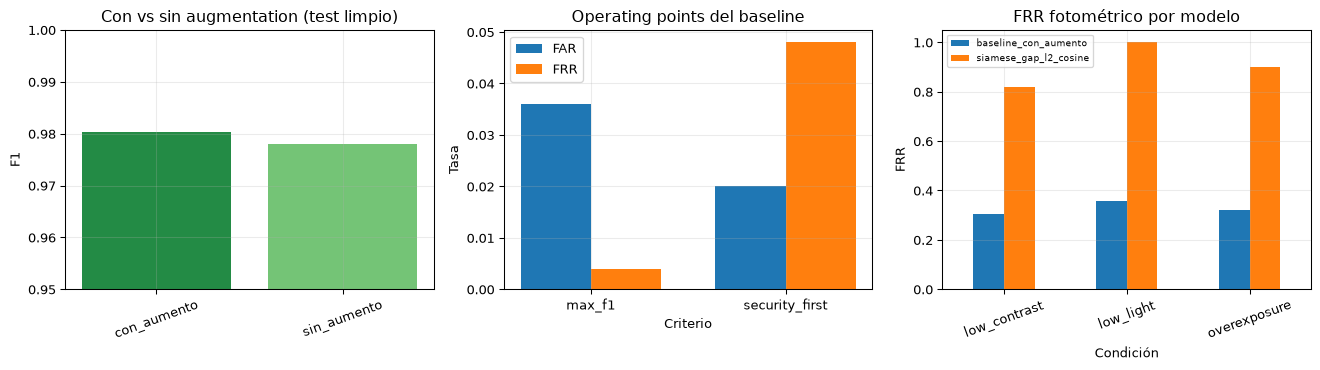

Fuente fotométrica: outputs/experiments/model_comparison/photometric_metrics.csv


In [15]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4))
axes[0].bar(aug_view['variant'], aug_view['f1'], color=['#238b45','#74c476'])
axes[0].set(title='Con vs sin augmentation (test limpio)', ylabel='F1', ylim=(0.95,1.0))
axes[0].tick_params(axis='x', rotation=20)

x = range(len(threshold_view))
axes[1].bar([i-0.18 for i in x], threshold_view['test_far'], width=0.36, label='FAR')
axes[1].bar([i+0.18 for i in x], threshold_view['test_frr'], width=0.36, label='FRR')
axes[1].set_xticks(list(x), threshold_view['criterion'])
axes[1].set(title='Operating points del baseline', ylabel='Tasa', xlabel='Criterio')
axes[1].legend()

pivot = photometric.pivot(index='condition', columns='model', values='frr')
pivot.plot.bar(ax=axes[2])
axes[2].set(title='FRR fotométrico por modelo', ylabel='FRR', xlabel='Condición')
axes[2].tick_params(axis='x', rotation=20)
axes[2].legend(fontsize=7)
fig.tight_layout(); plt.show()
print('Fuente fotométrica:', rel(MODEL_COMPARISON/'photometric_metrics.csv'))


## 13. Calibración del threshold

Los candidatos se seleccionaron exclusivamente con validation. `max_f1` maximiza el desempeño agregado. `security_first` exige primero `FAR <= 2%` y `FRR <= 5%` en validation, luego prioriza menor FAR y desempata por mayor F1. Test y stress no participaron en la selección.

Subir el threshold de `0.0187880173` a `0.3128704727` reduce FP de test de 9 a 5 y aumenta FN de 1 a 12: más seguridad, con fricción cuantificada.


In [16]:
cal_view = threshold_view.copy()
cal_view.columns = ['Criterio','Threshold','Val FAR','Val FRR','Val F1','Test accuracy','Test F1','Test FAR','Test FRR','Test FP','Test FN']
display(cal_view.style.hide(axis='index'))
print('Política:', calibration['security_first_policy'])
print('Fuente:', rel(FINAL_DIR/'security_threshold_calibration'/'security_threshold_calibration.json'))


Criterio,Threshold,Val FAR,Val FRR,Val F1,Test accuracy,Test F1,Test FAR,Test FRR,Test FP,Test FN
max_f1,0.018788,0.024000,0.008000,0.984127,0.980000,0.980315,0.036000,0.004000,9,1
security_first,0.312870,0.020000,0.028000,0.975904,0.966000,0.965517,0.020000,0.048000,5,12


Política: Menor FAR entre thresholds con FAR <= 2% y FRR <= 5% en validation; desempate por mayor F1. Si no existe, mejor F1 con FAR <= 2%; después FAR <= 3%; finalmente menor FAR disponible.
Fuente: outputs/experiments/baseline_formal/baseline_con_aumento/security_threshold_calibration/security_threshold_calibration.json


## 14. Modelo final

**Modelo:** `baseline_formal/baseline_con_aumento`  
**Threshold:** `0.3128704727`  
**Regla facial:** `score >= 0.3128704727 => MATCH`; en otro caso `NO_MATCH`.  
**Regla de acceso:** `RFID conocido + usuario activo + rostro verificado => GRANTED`; cualquier otro caso `DENIED`.


Accuracy,Precision,Recall,F1,FAR,FRR,ROC AUC,TN,FP,FN,TP
0.9660,0.9794,0.9520,0.9655,0.0200,0.0480,0.9838,245,5,12,238


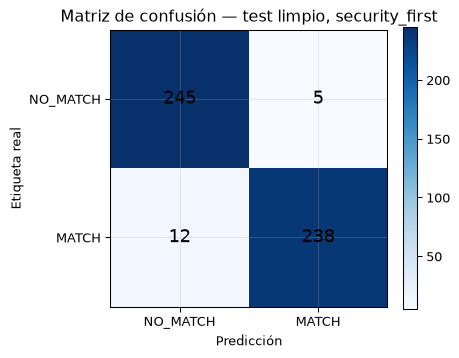

Fuentes: outputs/experiments/model_comparison/threshold_metrics.csv , config/model_config.json


In [17]:
final_metrics = pd.DataFrame([{
    'Accuracy': final_row.test_accuracy, 'Precision': final_row.test_precision,
    'Recall': final_row.test_recall, 'F1': final_row.test_f1,
    'FAR': final_row.test_far, 'FRR': final_row.test_frr,
    'ROC AUC': final_row.test_roc_auc, 'TN': int(final_row.test_tn),
    'FP': int(final_row.test_fp), 'FN': int(final_row.test_fn), 'TP': int(final_row.test_tp),
}])
display(final_metrics.style.hide(axis='index').format(precision=4))

cm = [[int(final_row.test_tn), int(final_row.test_fp)], [int(final_row.test_fn), int(final_row.test_tp)]]
fig, ax = plt.subplots(figsize=(4.8,4.2))
image = ax.imshow(cm, cmap='Blues')
for i,row in enumerate(cm):
    for j,value in enumerate(row): ax.text(j,i,value,ha='center',va='center',fontsize=14)
ax.set_xticks([0,1], ['NO_MATCH','MATCH']); ax.set_yticks([0,1], ['NO_MATCH','MATCH'])
ax.set(xlabel='Predicción', ylabel='Etiqueta real', title='Matriz de confusión — test limpio, security_first')
fig.colorbar(image, ax=ax, fraction=0.046); fig.tight_layout(); plt.show()
print('Fuentes:', rel(MODEL_COMPARISON/'threshold_metrics.csv'), ',', rel(ROOT/'config'/'model_config.json'))


## 15. Análisis de errores y stress tests

En test limpio hubo **5 FP** (impostores aceptados) y **12 FN** (genuinos rechazados). Los FP afectan seguridad; los FN afectan disponibilidad y equidad. Los stress tests modifican solo la imagen probe, usan seed 2026 y son evaluación secundaria sintética, no datos de calibración.


Condición,Accuracy,F1,FAR,FRR
Poca luz,0.782000,0.747100,0.080000,0.356000
Sobreexposición,0.832000,0.801887,0.016000,0.320000
Bajo contraste,0.816000,0.790909,0.064000,0.304000
Ruido,0.918000,0.911828,0.012000,0.152000
Desenfoque,0.952000,0.950820,0.024000,0.072000
Rotación/recorte,0.952000,0.950617,0.020000,0.076000
Oclusión parcial,0.938000,0.935282,0.020000,0.104000
Lentes sintéticos,0.958000,0.957055,0.020000,0.064000
Sombra de barba,0.906000,0.898488,0.020000,0.168000


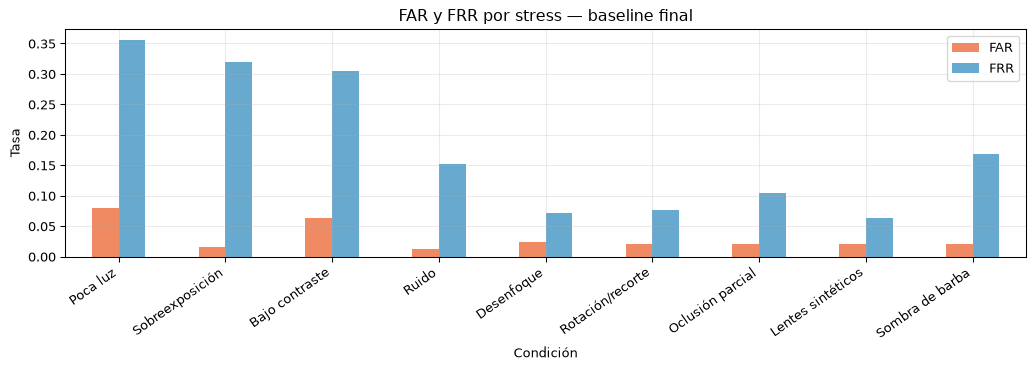

Fuente: outputs/experiments/model_comparison/stress_metrics_security_first.csv


In [18]:
stress = stress_all[
    stress_all['model'].eq('baseline_con_aumento') & stress_all['criterion'].eq('security_first')
][['condition','accuracy','f1','far','frr']].copy()
labels = {'low_light':'Poca luz','overexposure':'Sobreexposición','low_contrast':'Bajo contraste','noise':'Ruido','blur':'Desenfoque','rotation_crop':'Rotación/recorte','partial_occlusion':'Oclusión parcial','synthetic_glasses':'Lentes sintéticos','synthetic_beard_shadow':'Sombra de barba'}
stress['Condición'] = stress['condition'].map(labels)
display(stress[['Condición','accuracy','f1','far','frr']].rename(columns={'accuracy':'Accuracy','f1':'F1','far':'FAR','frr':'FRR'}).style.hide(axis='index'))

plot = stress.set_index('Condición')[['far','frr']]
plot.plot.bar(figsize=(11,4), color=['#ef8a62','#67a9cf'])
plt.title('FAR y FRR por stress — baseline final'); plt.xlabel('Condición'); plt.ylabel('Tasa'); plt.xticks(rotation=35, ha='right'); plt.legend(['FAR','FRR']); plt.tight_layout(); plt.show()
print('Fuente:', rel(MODEL_COMPARISON/'stress_metrics_security_first.csv'))


In [19]:
error_analysis = pd.DataFrame([
    ('5 FP en test limpio', 'FAR 0.020; 5/250 negativos', 'Acceso facial indebido', 'Mantener doble factor, revisar referencias y ampliar impostores'),
    ('12 FN en test limpio', 'FRR 0.048; 12/250 positivos', 'Usuario legítimo rechazado', 'Recaptura y referencias múltiples'),
    ('Poca luz', 'FRR 0.356', 'Mayor denegación legítima', 'Iluminación frontal y control de calidad'),
    ('Sobreexposición', 'FRR 0.320', 'Pérdida de rasgos', 'Evitar contraluz y recapturar'),
    ('Bajo contraste', 'FRR 0.304', 'Score genuino insuficiente', 'Más sesiones reales; evaluar CLAHE, no asumirlo implementado'),
], columns=['Error/condición', 'Evidencia', 'Impacto', 'Mitigación'])
display(error_analysis.style.hide(axis='index'))


Error/condición,Evidencia,Impacto,Mitigación
5 FP en test limpio,FAR 0.020; 5/250 negativos,Acceso facial indebido,"Mantener doble factor, revisar referencias y ampliar impostores"
12 FN en test limpio,FRR 0.048; 12/250 positivos,Usuario legítimo rechazado,Recaptura y referencias múltiples
Poca luz,FRR 0.356,Mayor denegación legítima,Iluminación frontal y control de calidad
Sobreexposición,FRR 0.320,Pérdida de rasgos,Evitar contraluz y recapturar
Bajo contraste,FRR 0.304,Score genuino insuficiente,"Más sesiones reales; evaluar CLAHE, no asumirlo implementado"


## 16. Mejoras implementadas


In [20]:
improvements = pd.DataFrame([
    ('Fuga por pares/frames correlacionados', 'Split por video antes de pares', 'Auditoría con cuatro ceros', 'Evaluación más válida'),
    ('Fragilidad a captura', 'Augmentation solo train', 'Stress acc. prom. 0.9502 vs 0.8282', 'Mayor robustez promedio'),
    ('Falta de evaluación difícil', 'Stress tests deterministas', '9 condiciones, seed 2026', 'Errores visibles y comparables'),
    ('FAR alto en max_f1', 'Threshold security_first', 'FP 9→5', 'Prioridad de seguridad explícita'),
    ('Arquitectura no contrastada', 'Variante GAP+L2+coseno', 'Mejor limpio, fallo fotométrico', 'Descarte basado en evidencia'),
    ('Inferencia dispersa', 'Paquete src/inference', 'CLI y configuración común', 'Contrato único'),
    ('Sin flujo demostrable', 'Web FastAPI + historial', 'Rutas y servicios probados', 'Integración funcional'),
    ('Pruebas manuales frágiles', 'Suite y smoke test', 'Tests unitarios/integrales', 'Regresión detectable'),
], columns=['Problema detectado', 'Mejora aplicada', 'Evidencia', 'Impacto'])
display(improvements.style.hide(axis='index'))


Problema detectado,Mejora aplicada,Evidencia,Impacto
Fuga por pares/frames correlacionados,Split por video antes de pares,Auditoría con cuatro ceros,Evaluación más válida
Fragilidad a captura,Augmentation solo train,Stress acc. prom. 0.9502 vs 0.8282,Mayor robustez promedio
Falta de evaluación difícil,Stress tests deterministas,"9 condiciones, seed 2026",Errores visibles y comparables
FAR alto en max_f1,Threshold security_first,FP 9→5,Prioridad de seguridad explícita
Arquitectura no contrastada,Variante GAP+L2+coseno,"Mejor limpio, fallo fotométrico",Descarte basado en evidencia
Inferencia dispersa,Paquete src/inference,CLI y configuración común,Contrato único
Sin flujo demostrable,Web FastAPI + historial,Rutas y servicios probados,Integración funcional
Pruebas manuales frágiles,Suite y smoke test,Tests unitarios/integrales,Regresión detectable


## 17. Inferencia y demo web

```text
UID simulado → búsqueda de usuario → estado activo → referencias → captura
→ modelo siamés → score → threshold → MATCH/NO_MATCH
→ GRANTED/DENIED → historial
```

El **RFID es simulado** mediante entrada de UID en la web. La lógica de doble factor está implementada; el lector y ESP32 físicos no lo están. Fallos de configuración o inferencia se resuelven de forma segura como `DENIED`.

**Rutas principales:** `config/model_config.json`, `src/inference/`, `src/web/`, `scripts/run_web_demo_smoke_test.py`.


In [21]:
access_cases = pd.DataFrame([
    ('UID conocido, activo + MATCH', 'GRANTED', 'RFID_AND_FACE_OK', 'Sí'),
    ('UID desconocido', 'DENIED', 'RFID_UNKNOWN', 'No'),
    ('Usuario inactivo', 'DENIED', 'USER_INACTIVE', 'No'),
    ('UID activo + NO_MATCH', 'DENIED', 'FACE_NO_MATCH', 'Sí'),
], columns=['Entrada', 'Decisión', 'Motivo', 'Ejecuta inferencia facial'])
display(access_cases.style.hide(axis='index'))


Entrada,Decisión,Motivo,Ejecuta inferencia facial
"UID conocido, activo + MATCH",GRANTED,RFID_AND_FACE_OK,Sí
UID desconocido,DENIED,RFID_UNKNOWN,No
Usuario inactivo,DENIED,USER_INACTIVE,No
UID activo + NO_MATCH,DENIED,FACE_NO_MATCH,Sí


## 18. Pruebas integrales

El smoke test integral se ejecutó contra una instancia temporal local; no se guardaron imágenes, base ni rutas. `USER_INACTIVE` está cubierto por pruebas automatizadas de servicio y ruta, aunque el script de smoke no cambia el estado del usuario.


In [22]:
tests_view = pd.DataFrame([
    ('Health', 'OK', 'Smoke test temporal', 'scripts/run_web_demo_smoke_test.py'),
    ('Registro', 'OK', 'Smoke test temporal', 'scripts/run_web_demo_smoke_test.py'),
    ('GRANTED', 'OK', 'Smoke test temporal', 'scripts/run_web_demo_smoke_test.py'),
    ('RFID_UNKNOWN', 'OK', 'Smoke test temporal', 'scripts/run_web_demo_smoke_test.py'),
    ('FACE_NO_MATCH', 'OK', 'Smoke test temporal', 'scripts/run_web_demo_smoke_test.py'),
    ('Historial', 'OK', 'Smoke test temporal', 'scripts/run_web_demo_smoke_test.py'),
    ('USER_INACTIVE', 'OK', 'Prueba automatizada', 'tests/test_web_access_flow.py; tests/test_web_routes.py'),
], columns=['Caso', 'Resultado', 'Tipo de evidencia', 'Fuente'])
display(tests_view.style.hide(axis='index'))


Caso,Resultado,Tipo de evidencia,Fuente
Health,OK,Smoke test temporal,scripts/run_web_demo_smoke_test.py
Registro,OK,Smoke test temporal,scripts/run_web_demo_smoke_test.py
GRANTED,OK,Smoke test temporal,scripts/run_web_demo_smoke_test.py
RFID_UNKNOWN,OK,Smoke test temporal,scripts/run_web_demo_smoke_test.py
FACE_NO_MATCH,OK,Smoke test temporal,scripts/run_web_demo_smoke_test.py
Historial,OK,Smoke test temporal,scripts/run_web_demo_smoke_test.py
USER_INACTIVE,OK,Prueba automatizada,tests/test_web_access_flow.py; tests/test_web_routes.py


## 19. Limitaciones y mejoras futuras


In [23]:
limits_future = pd.DataFrame([
    ('11 identidades y pocas sesiones', 'Más personas, sesiones y condiciones reales'),
    ('Identidades conocidas en todos los splits', 'Protocolo pre-registrado de identidades no vistas'),
    ('Stress sintético; sin validation-stress', 'Crear validation-stress independiente antes de explorar'),
    ('Sensibilidad fotométrica', 'Control de calidad y evaluar CLAHE con paridad train/inferencia'),
    ('RFID simulado; sin ESP32', 'Integración serial y pruebas con hardware físico'),
    ('Sin liveness', 'Detección de presentación y pruebas de ataque'),
    ('Demo local sin autenticación/HTTPS', 'Roles, secretos, HTTPS, hardening y auditoría'),
    ('Sin backbone preentrenado', 'MobileNetV2 congelado y luego fine-tuning selectivo'),
    ('Sin validación externa/equidad', 'Evaluación externa y por subgrupos con consentimiento'),
], columns=['Limitación actual', 'Mejora futura realista'])
display(limits_future.style.hide(axis='index'))


Limitación actual,Mejora futura realista
11 identidades y pocas sesiones,"Más personas, sesiones y condiciones reales"
Identidades conocidas en todos los splits,Protocolo pre-registrado de identidades no vistas
Stress sintético; sin validation-stress,Crear validation-stress independiente antes de explorar
Sensibilidad fotométrica,Control de calidad y evaluar CLAHE con paridad train/inferencia
RFID simulado; sin ESP32,Integración serial y pruebas con hardware físico
Sin liveness,Detección de presentación y pruebas de ataque
Demo local sin autenticación/HTTPS,"Roles, secretos, HTTPS, hardening y auditoría"
Sin backbone preentrenado,MobileNetV2 congelado y luego fine-tuning selectivo
Sin validación externa/equidad,Evaluación externa y por subgrupos con consentimiento


## 20. Reproducibilidad técnica

- Python y TensorFlow se declaran en `requirements.txt`.
- Seed 42 para entrenamiento; seed 2026 para stress.
- Rutas relativas y configuración única en `config/model_config.json`.
- El notebook solo lee JSON/CSV pequeños y no requiere datos privados.
- El reentrenamiento excepcional debe hacerse deliberadamente; para GPU NVIDIA moderna en Windows se documenta WSL2, pero **este notebook no necesita GPU**.

```powershell
python -m compileall -q src tests
python -m unittest discover -s tests -v
python -m src.inference.cli check-model --config config/model_config.json
python -m src.web.app
python scripts/run_web_demo_smoke_test.py --health-only
python -m nbconvert --to html --execute notebooks/99_project_summary.ipynb
```

**Fuentes:** `requirements.txt`, `config/model_config.json`, `docs/final_usage_guide.md`, `docs/gpu_training_setup.md`.


## 21. Ética, sesgos y uso responsable

Los rostros son datos sensibles. Se requiere consentimiento informado, propósito limitado, minimización, acceso restringido, retención definida y eliminación segura. El repositorio no debe incluir rostros, videos, support sets, bases, modelos ni rutas privadas.

El dataset pequeño y las condiciones de captura limitadas pueden producir sesgo y métricas inestables. Un FAR alto compromete seguridad; un FRR alto deniega acceso legítimo y puede afectar de forma desigual. El prototipo es académico, no productivo: cualquier despliegue requiere validación externa, evaluación de equidad, liveness, seguridad contra presentación, autenticación, cifrado y revisión humana.


## 22. Conclusiones

1. Corregir la fuga por video fue más importante que optimizar sobre splits contaminados.
2. El augmentation produjo una mejora pequeña en limpio y marcada en robustez promedio.
3. `security_first` conserva FAR 2% en test con el costo explícito de FRR 4.8%.
4. GAP + L2 + coseno fue más compacto y mejor en limpio, pero falló en las degradaciones fotométricas críticas.
5. La demo demuestra la lógica integral RFID simulado + rostro + historial, no un sistema biométrico productivo.
6. MobileNetV2, fine-tuning, distillation, liveness y ESP32 permanecen como trabajo futuro, no como resultados.


## 23. Matriz final de cobertura de la rúbrica


In [24]:
rubric = pd.DataFrame([
    (1,'Definición y justificación del problema','§1','Riesgo RFID y verificación de pares','Implementado y evidenciado.'),
    (2,'Objetivos e indicadores','§2','Tabla cuantitativa y funcional','Implementado y evidenciado.'),
    (3,'EDA','§3','Agregados, tablas y cuatro gráficos','Implementado y evidenciado.'),
    (4,'Limpieza y transformación','§4','Código, umbrales y pipeline','Implementado y evidenciado.'),
    (5,'División y fuga','§5','Split por video y auditoría con ceros','Implementado y evidenciado.'),
    (6,'Modelo baseline','§6','Arquitectura, funciones y parámetros','Implementado y evidenciado.'),
    (7,'Configuración de entrenamiento','§7','Config real y justificación','Implementado y evidenciado.'),
    (8,'Control de experimentos','§8','Hipótesis, variables y decisión','Implementado y evidenciado.'),
    (9,'Feature extraction','§9–10','Encoder propio y variante GAP; sin extractor preentrenado','Parcialmente cubierto.'),
    (10,'Fine-tuning','§10','No hubo backbone preentrenado consolidado','No implementado; justificado.'),
    (11,'Teacher-student / distillation','§10','Sin teacher validado ni necesidad crítica','No implementado; justificado.'),
    (12,'Técnica complementaria','§9, §13, §15','Augmentation, threshold y stress','Implementado y evidenciado.'),
    (13,'Selección de métricas','§11, §14','FAR/FRR, ROC AUC y matriz','Implementado y evidenciado.'),
    (14,'Comparación de experimentos','§12–13','Cuatro comparaciones controladas','Implementado y evidenciado.'),
    (15,'Errores e interpretación','§15','FP/FN, stress, impacto y mitigación','Implementado y evidenciado.'),
    (16,'Mejoras implementadas','§16','Tabla problema-mejora-impacto','Implementado y evidenciado.'),
    (17,'Limitaciones y futuro','§19','Separación explícita','Implementado y evidenciado.'),
    (18,'Organización y reproducibilidad','§20','Seeds, config, requisitos y comandos','Implementado y evidenciado.'),
    (19,'Presentación técnica y defensa','§0–24','Recorrido lineal y preguntas','Implementado y evidenciado.'),
    (20,'Ética, sesgos y uso responsable','§21','Privacidad, riesgo, equidad y alcance','Implementado y evidenciado.'),
], columns=['N.º','Criterio','Sección del notebook','Evidencia','Estado'])
display(rubric.style.hide(axis='index'))


N.º,Criterio,Sección del notebook,Evidencia,Estado
1,Definición y justificación del problema,§1,Riesgo RFID y verificación de pares,Implementado y evidenciado.
2,Objetivos e indicadores,§2,Tabla cuantitativa y funcional,Implementado y evidenciado.
3,EDA,§3,"Agregados, tablas y cuatro gráficos",Implementado y evidenciado.
4,Limpieza y transformación,§4,"Código, umbrales y pipeline",Implementado y evidenciado.
5,División y fuga,§5,Split por video y auditoría con ceros,Implementado y evidenciado.
6,Modelo baseline,§6,"Arquitectura, funciones y parámetros",Implementado y evidenciado.
7,Configuración de entrenamiento,§7,Config real y justificación,Implementado y evidenciado.
8,Control de experimentos,§8,"Hipótesis, variables y decisión",Implementado y evidenciado.
9,Feature extraction,§9–10,Encoder propio y variante GAP; sin extractor preentrenado,Parcialmente cubierto.
10,Fine-tuning,§10,No hubo backbone preentrenado consolidado,No implementado; justificado.


## 24. Preguntas clave para la defensa

| Pregunta | Respuesta breve (20–40 s) |
|---|---|
| ¿Por qué una red siamesa? | Porque el objetivo es comparar una captura con referencias, no asignar una clase fija. Los pesos compartidos producen embeddings comparables y permiten enrolar referencias nuevas sin reentrenar una salida por persona. |
| ¿Por qué no un clasificador de 11 clases? | Un clasificador cerrado aprendería únicamente esas 11 etiquetas y exigiría reentrenar al agregar usuarios. La verificación de pares coincide mejor con el flujo UID → referencias → captura. |
| ¿Qué era la fuga de datos? | Formar pares antes del split podía colocar la misma imagen o frames casi idénticos de un video en train y evaluación. Eso permitía memorizar la captura y sobreestimar el rendimiento. |
| ¿Por qué split por video? | El video es la unidad correlacionada. Mantenerlo completo en un split evita compartir frames y evalúa nuevas capturas de identidades conocidas, aunque todavía no identidades nuevas. |
| ¿Qué representa el threshold? | Es el punto operativo que convierte el score continuo en MATCH o NO_MATCH. Se calibró solo con validation; `0.3128704727` prioriza FAR bajo sin permitir FRR descontrolado. |
| ¿Por qué no usar solo accuracy? | Accuracy mezcla ambos tipos de error. En acceso importa distinguir impostores aceptados —FAR— de usuarios legítimos rechazados —FRR— porque sus impactos operativos y éticos son distintos. |
| ¿Qué diferencia hay entre FAR y FRR? | FAR es la fracción de negativos aceptados y mide riesgo de intrusión. FRR es la fracción de genuinos rechazados y mide fricción o denegación legítima. |
| ¿Por qué se descartó GAP + L2 + coseno? | Tenía 1,062,400 parámetros y mejor test limpio, pero su FRR llegó a 1.00, 0.90 y 0.82 en poca luz, sobreexposición y bajo contraste. Falló justo donde se buscaba robustez. |
| ¿Por qué no se usó MobileNetV2? | Abrir otra búsqueda después de observar test-stress habría sido metodológicamente oportunista. Debe evaluarse en una sesión futura pre-registrada, primero congelado y con validation-stress separado. |
| ¿Por qué no se hizo fine-tuning? | No había un backbone preentrenado consolidado y el dataset de 11 identidades aumenta el riesgo de sobreajuste. Primero debe validarse transferencia congelada y después liberar pocos bloques con learning rate bajo. |
| ¿Por qué RFID es simulado? | El hardware físico quedó fuera del alcance temporal. La web sustituye la fuente del UID, pero conserva la misma lógica UID → usuario → rostro → decisión → historial. |
| ¿Qué ocurre en poca luz? | El baseline final alcanza FRR 0.356: rechaza más genuinos porque se degradan rasgos útiles. La mitigación inmediata es recaptura, luz frontal, control de calidad y múltiples referencias. |
| ¿Cómo se mitigaría en producción? | Con más identidades y sesiones, validation-stress independiente, control de calidad, liveness, evaluación externa, autenticación/HTTPS, monitoreo de FAR/FRR y revisión humana. |
| ¿Dónde está el código de arquitectura? | En `src/models/siamese_network.py`: `build_embedding_network()` crea el encoder y `build_siamese_model()` conecta ambas ramas, L1 y sigmoid. |
| ¿Dónde está el código de inferencia? | En `src/inference/`: configuración, carga, preprocesamiento, verificación y decisión. La web reutiliza ese paquete y el mismo `model_config.json`. |
| ¿Qué demuestra la web? | Demuestra registro, UID conocido o desconocido, estado activo, comparación facial, regla AND, GRANTED/DENIED y persistencia del historial. No demuestra ESP32 ni preparación productiva. |

**Cierre sugerido:** el principal aporte no es una cifra aislada, sino un protocolo sin fuga, una selección de seguridad trazable, análisis de robustez y una integración funcional con limitaciones explícitas.
